# AI-Based Ocean Temperature Prediction


## Context and motivation


The Argo program is a global network of over 4,000 autonomous profiling floats deployed across the world's oceans. Each float dives to depths of up to 2,000 metres, measuring temperature, salinity and pressure as it rises, before surfacing to transmit its data via satellite.

While temperature can be measured directly by a sensor, a predictive model built on Argo data has an important practical application in quality control. When a float transmits a temperature reading, an automated pipeline can compare it against what the model predicts given the depth, salinity, location and time of year. A large discrepancy — for example a reading of 25°C at 800m depth in January — would be flagged as a likely sensor malfunction. This is more powerful than simple range checks because it accounts for physical context, and is actively used in operational Argo data pipelines.

This project builds an end-to-end ML pipeline on Argo data from the Ligurian Sea (coast of Antibes, France), comparing a linear regression baseline against a Random Forest model to predict ocean temperature from depth, salinity, geographic position and seasonality.

## Setup and Data Loading

### Library installations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

### Extraction of the dataset

In [2]:
df = pd.read_csv("argo_ligurian_sea.csv")
df.head()

,latitude,longitude,pressure_dbar,temperature_c,salinity_psu,month_sin,month_cos,depth_m
0,43.714,8.345,6.0,13.546,38.3366,0.5,0.866025,6.02
1,43.714,8.345,7.0,13.547,38.3376,0.5,0.866025,7.02
2,43.714,8.345,8.0,13.539,38.3376,0.5,0.866025,8.02
3,43.714,8.345,9.0,13.556,38.3366,0.5,0.866025,9.02
4,43.714,8.345,10.0,13.557,38.3366,0.5,0.866025,10.03


In [3]:
print(df.shape)
print(df.dtypes)

(125099, 8)
latitude         float64
longitude        float64
pressure_dbar    float64
temperature_c    float64
salinity_psu     float64
month_sin        float64
month_cos        float64
depth_m          float64
dtype: object


The dataset has 125,099 rows. 
All the data is represented by 64-bit floating numbers, i.e numerical: nothing to convert.

## Statistical analysis of the dataset

### Extraction of statistical measures

In [4]:
df.describe()

,latitude,longitude,pressure_dbar,temperature_c,salinity_psu,month_sin,month_cos,depth_m
count,125099.000000,125099.000000,125099.000000,125099.000000,125099.000000,1.250990e+05,1.250990e+05,125099.000000
mean,42.993279,7.451436,707.705815,13.696369,38.536249,-2.655232e-01,-2.383853e-02,707.764712
std,0.398316,0.648344,519.858256,1.006023,0.124439,5.625562e-01,7.826028e-01,519.217357
min,42.500200,6.026800,0.200000,13.119000,37.131000,-1.000000e+00,-1.000000e+00,0.200000
25%,42.649700,7.089300,251.000000,13.253000,38.500000,-8.660254e-01,-8.660254e-01,251.490000
50%,42.842900,7.507000,617.200000,13.528000,38.546200,-5.000000e-01,-1.836970e-16,617.880000
75%,43.344200,7.903100,1112.700000,13.804000,38.620000,1.224647e-16,8.660254e-01,1112.720000
max,43.912900,8.494600,1998.300000,26.052000,38.730200,1.000000e+00,1.000000e+00,1994.440000


Temperature: the mean is 13.7°C, but a standard deviation of 1°C. It seems that most of the data is deep water.

Depth: the mean is 700m, but the median is 617m. This means that more than half of the data is deeper than 600m.

Depth and Pressure are proportional, the coefficient of proportionality is very close to 1 (due to the choice of units).

### Checking for missing values

In [5]:
df.isnull().sum()

latitude         0
longitude        0
pressure_dbar    0
temperature_c    0
salinity_psu     0
month_sin        0
month_cos        0
depth_m          0
dtype: int64

There are no missing values.

### Histograms

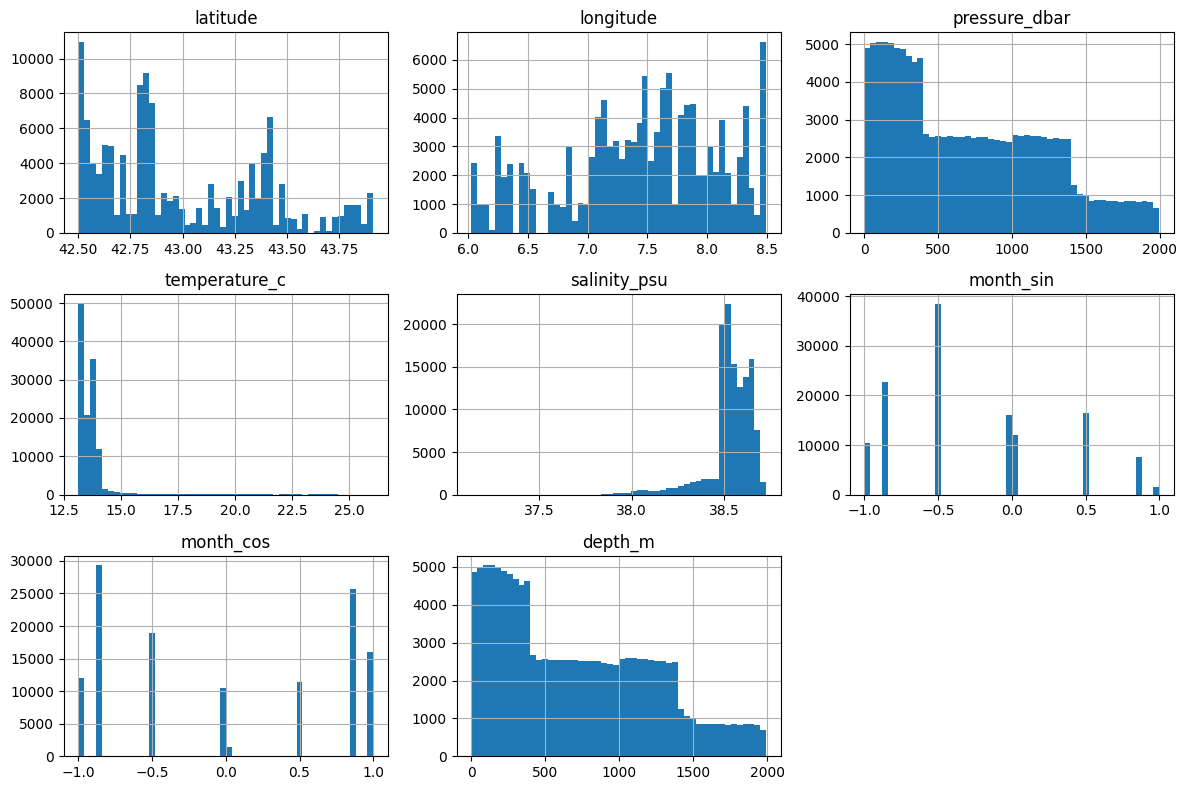

In [6]:
df.hist(figsize=(12, 8), bins=50)
#Each histogram is divided into 50 bars to give decent detail
plt.tight_layout()
#Prevents the subplots from overlapping
plt.show()

Temperature: right-skewed distribution implying most data is in deep cold waters

Depth: Probe has a few preferred sampling depths rather than a perfectly uniform distribution. Not a problem, as there is good coverage across all depths

Apparent contradiction between temperature and depth: below 300m, temperature barely changes, reflecting the thermal structure of the Mediterranean (warm surface layer and deep uniform mass underneath)

Salinity: extremely stable

### Boxplots

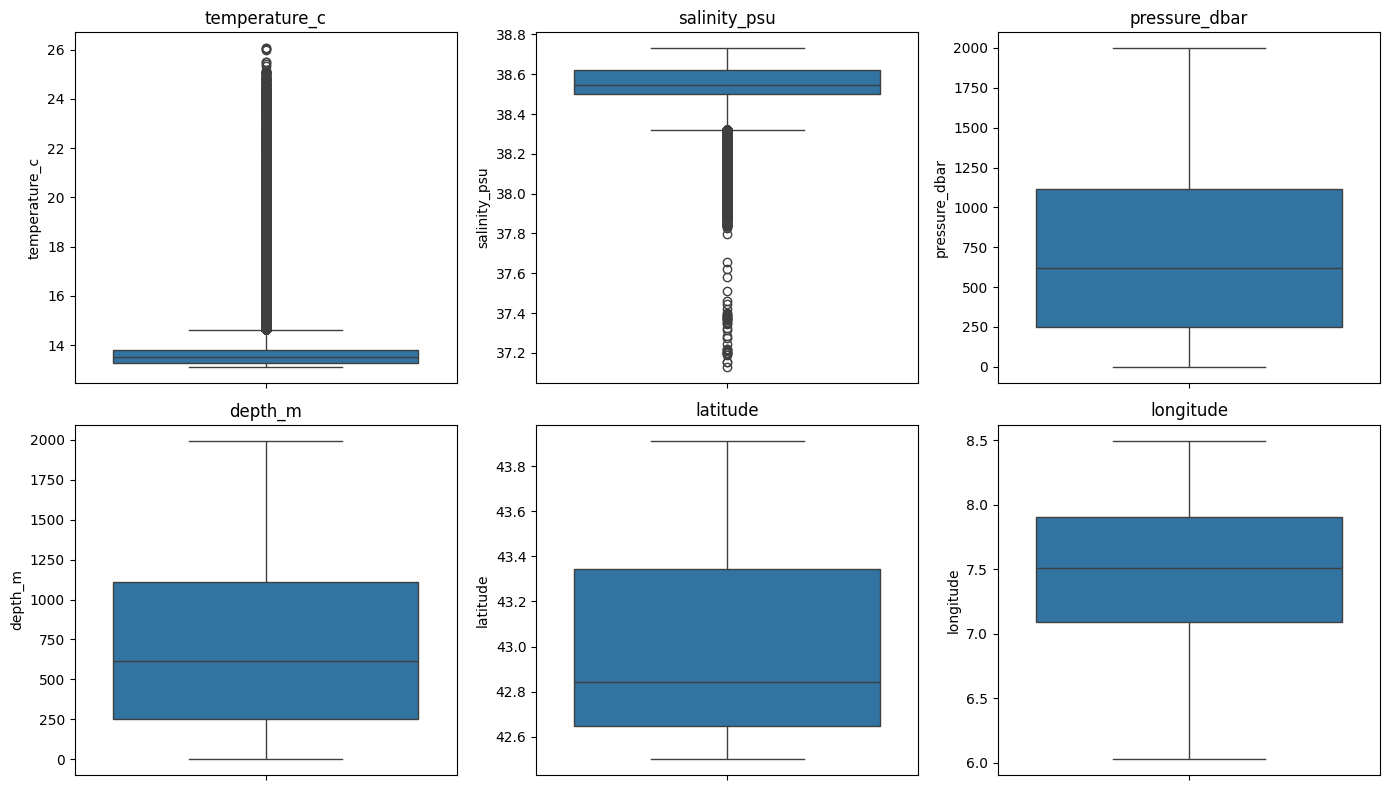

In [7]:
cols = ['temperature_c', 'salinity_psu', 'pressure_dbar', 'depth_m', 'latitude', 'longitude']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

No sense in making a boxplot for month_sin and month_cos

Temperature: Measurements above the whisker aren't outliers, we will treat them as physically real surface summer temperatures

Salinity: Measurements below 37.5 are candidates for removal, they could be sensor errors



### Zoom-in on salinity outliers

In [8]:
df[df['salinity_psu'] < 37.5]

,latitude,longitude,pressure_dbar,temperature_c,salinity_psu,month_sin,month_cos,depth_m
100005,42.7833,7.0356,3.0,20.580,37.380,-0.5,-0.866025,3.01
100006,42.7833,7.0356,5.5,20.359,37.131,-0.5,-0.866025,5.51
100007,42.7833,7.0356,6.5,20.343,37.245,-0.5,-0.866025,6.52
100008,42.7833,7.0356,7.5,20.316,37.217,-0.5,-0.866025,7.52
100009,42.7833,7.0356,8.5,20.297,37.222,-0.5,-0.866025,8.52
100010,42.7833,7.0356,9.5,20.288,37.199,-0.5,-0.866025,9.52
100011,42.7833,7.0356,10.5,20.280,37.202,-0.5,-0.866025,10.53
100012,42.7833,7.0356,11.5,20.275,37.210,-0.5,-0.866025,11.53
100013,42.7833,7.0356,14.9,20.251,37.153,-0.5,-0.866025,14.94
100014,42.7833,7.0356,16.2,20.246,37.189,-0.5,-0.866025,16.24


Firstly, these outliers represent 35 rows out of 125,000 , so they shouldn't distort training (0.03% of the data).

Secondly, they all come from the same single Argo float profile (same location and month), so they don't represent scattered errors. The low salinity is physically plausible (location close to the Var river, water may have been diluted by rain and river runoff).

### Correlation matrix

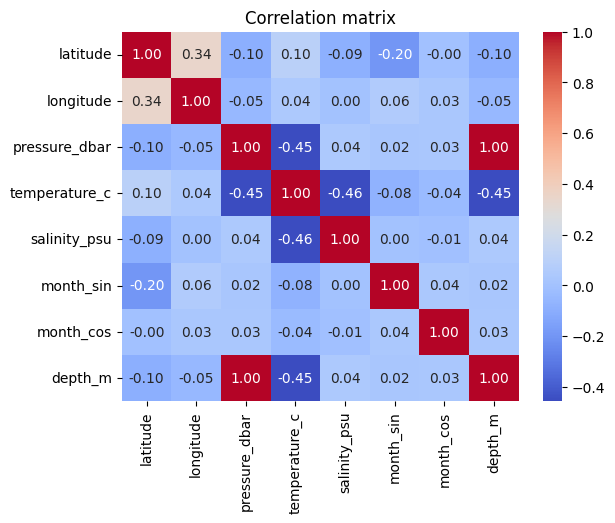

In [9]:
corr = df.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation matrix")
plt.show()

Target variable (label): Temperature

Pressure/Depth: stong (-0.45), makes sense because deeper waters are colder

Salinity: strong (-0.46), cold deep water is saltier than fresher warm surface layer

Latitude: weak (0.1), moving north means warmer waters

Seasonality: very weak, most measrements are in deep waters that are rarely affected by seasonality


From now on, we will dispose of Pressure in favour of Depth.

### Visualisation of the two most important relationships

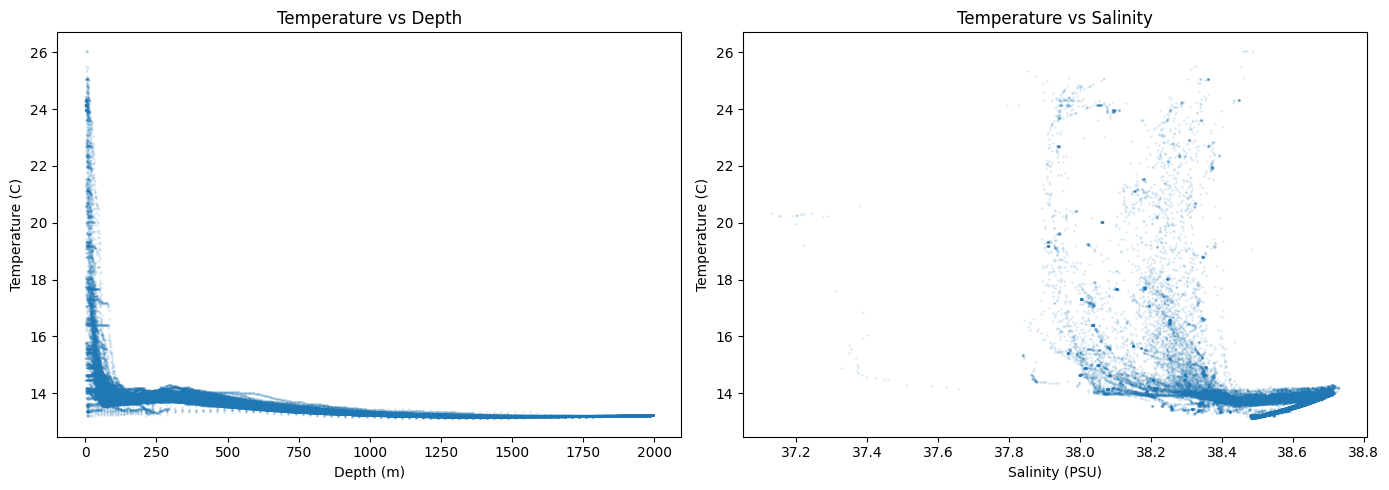

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df['depth_m'], df['temperature_c'], alpha=0.1, s=1)
axes[0].set_xlabel('Depth (m)')
axes[0].set_ylabel('Temperature (C)')
axes[0].set_title('Temperature vs Depth')

#alpha=0.1 makes dots more transparent, so that denser areas are more prominent
#s=1 makes data points small

axes[1].scatter(df['salinity_psu'], df['temperature_c'], alpha=0.1, s=1)
axes[1].set_xlabel('Salinity (PSU)')
axes[1].set_ylabel('Temperature (C)')
axes[1].set_title('Temperature vs Salinity')

plt.tight_layout()
plt.show()

Depth: thermocline curve (important in oceanography), the relationship is non-linear, a linear model will struggle to capture it well.

Salinity: very non-linear, we can identify 3 seperate clusters, a random-forest model may have to be used.

### Definition of features and labels

In [11]:
df = df.drop(columns=['pressure_dbar'],errors='ignore')
#errors=ignore makes sure that no error message appears if the cell is run when the pressure column has already been removed in a previous iteration

X = df.drop(columns=['temperature_c'])
#X is the features matrix
y = df['temperature_c']
#y is the label

print("Features:", list(X.columns))
print("Label:", y.name)
print("X shape:", X.shape)
print("y shape:", y.shape)

Features: ['latitude', 'longitude', 'salinity_psu', 'month_sin', 'month_cos', 'depth_m']
Label: temperature_c
X shape: (125099, 6)
y shape: (125099,)


### Splitting of the dataset into training, validation and test sets

In [12]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)
#The split is done in 2 steps
#random stae: rng that controls how data is split without giving different split every time the cell is run

print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)

Training set: (75059, 6)
Validation set: (25020, 6)
Test set: (25020, 6)


We will include a validation set, so as to reduce overfitting (so as to avoid tweaking with the test set): a 60-20-20 split.


### Feature scaling

In [13]:
scaler = StandardScaler()
#Transforms each feature to have a mean of 0 and a standard deviation of 1

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)
#Fit transform is only used on the training set.
# When fit transform is used here, it learns the mean and standard deviation of the training set
# When transform is then used on validation and test, it uses the mean and s.d of the training set
# All three sets are scaled using the exact same numbers
# The validation and test sets are scaled as if they were new data coming in after the model was built

print("Mean of training features (should be ~0):", X_train_scaled.mean(axis=0).round(3))
print("Std of training features (should be ~1):", X_train_scaled.std(axis=0).round(3))

Mean of training features (should be ~0): [ 0. -0. -0.  0.  0. -0.]
Std of training features (should be ~1): [1. 1. 1. 1. 1. 1.]


The features have been subjected to Z-score scaling ( z = (x-μ) / σ )

## First model: linear regression

In [15]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
#Creates an empty linear regression model
lr_model.fit(X_train_scaled, y_train)
#Model is trained

y_pred_val_lr = lr_model.predict(X_val_scaled)
#Trained model used on validation set to make predictions

mse_lr = mean_squared_error(y_val, y_pred_val_lr)
rmse_lr = mse_lr ** 0.5
r2_lr = r2_score(y_val, y_pred_val_lr)

print("Linear Regression - Validation set")
print("RMSE:", round(rmse_lr, 4))
print("R2:", round(r2_lr, 4))

Linear Regression - Validation set
RMSE: 0.767
R2: 0.408


RMSE: 0.767 °C

R2: 0.408

Poor performance as expected given the non-linear relationships.

Note: RMSE measures the average prediction error, R2 measures as a percentage how much of the variation in temperature the model explains. A good model will have a low RMSE and a high R2.

We are only using the validation set here. 
The validation set will be used to evaluate and compare models: linear regression here, possibly Random Forest later.
Once the best model is chosen, we will run it on the test set to obtain our final score.

## Second model: Random Forest 

### Establishing the model

In [16]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_val_rf = rf_model.predict(X_val)

mse_rf = mean_squared_error(y_val, y_pred_val_rf)
rmse_rf = mse_rf ** 0.5
r2_rf = r2_score(y_val, y_pred_val_rf)

print("Random Forest - Validation set")
print("RMSE:", round(rmse_rf, 4))
print("R2:", round(r2_rf, 4))

Random Forest - Validation set
RMSE: 0.1
R2: 0.9899


Excellent results.

RMSE divided by 8, and R2 shows that the model explains 99% of the variance in temperature.

A R2 of 0.99 is suspiciously high and worth questioning. It could mean the model is overfitting. We will check this when we run the final evaluation on the test set.

This result proves to us the non-linear relationship of the data.

### Comparison with model 1

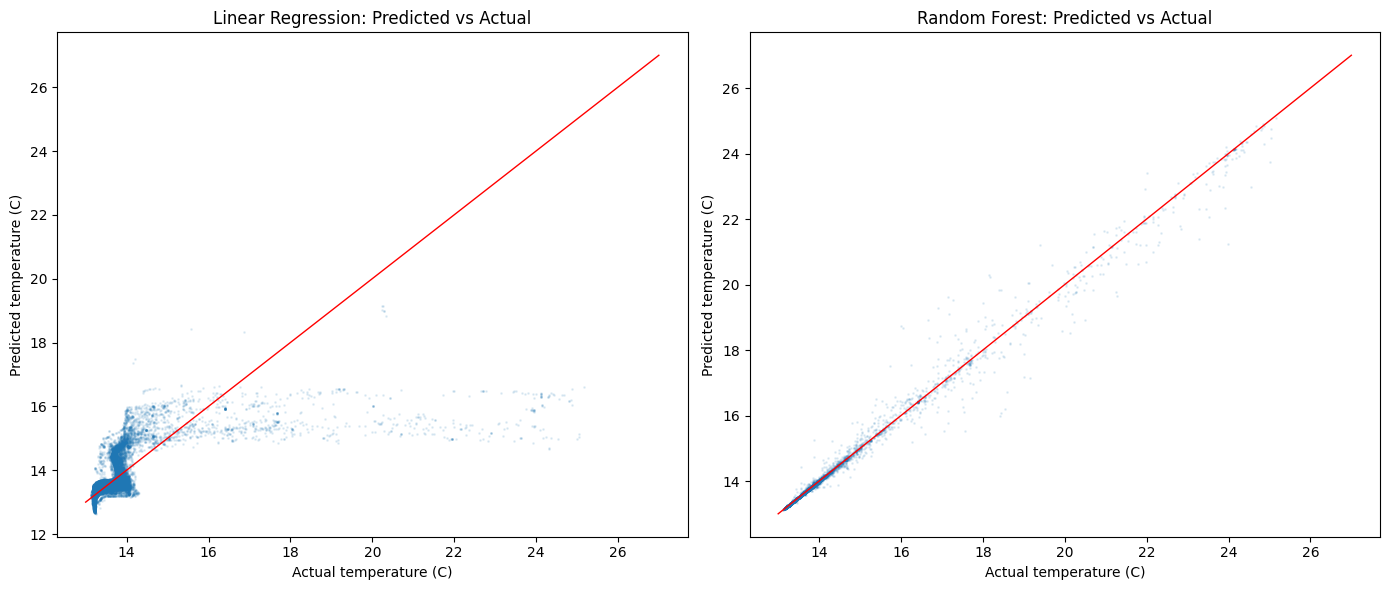

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(y_val, y_pred_val_lr, alpha=0.1, s=1)
axes[0].plot([13, 27], [13, 27], color='red', linewidth=1)
axes[0].set_xlabel('Actual temperature (C)')
axes[0].set_ylabel('Predicted temperature (C)')
axes[0].set_title('Linear Regression: Predicted vs Actual')

axes[1].scatter(y_val, y_pred_val_rf, alpha=0.1, s=1)
axes[1].plot([13, 27], [13, 27], color='red', linewidth=1)
axes[1].set_xlabel('Actual temperature (C)')
axes[1].set_ylabel('Predicted temperature (C)')
axes[1].set_title('Random Forest: Predicted vs Actual')

plt.tight_layout()
plt.show()

The red line represents the perfect prediction line, it represents where every point would sit if the model predicted every temperature exactly right.

We can see that model 2 is much more powerful than model 1.

### Feature importance

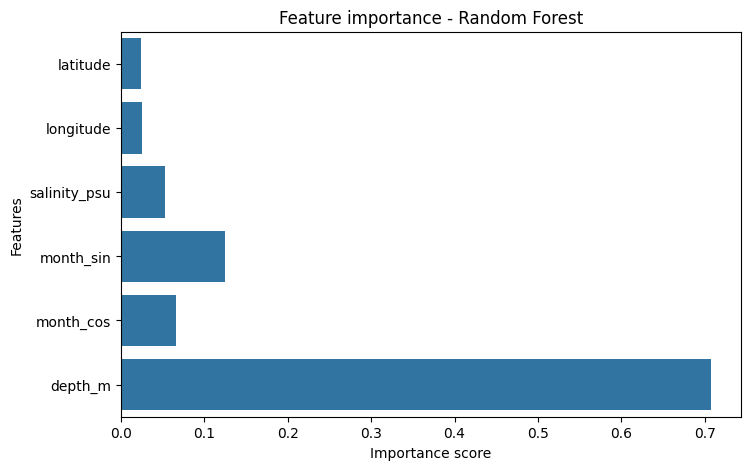

In [20]:
importances = rf_model.feature_importances_
features = X.columns

plt.figure(figsize=(8, 5))
sns.barplot(x=importances, y=features)
plt.title('Feature importance - Random Forest')
plt.xlabel('Importance score')
plt.ylabel('Features')
plt.show()

This graph shows us which features are the most important. 

The model independently confirms what physical oceanography tells us: temperature in the ocean is primarily determined by depth, then by season.

The geographic position within this relatively small region has almost no predictive power.

### Overfitting check

In [21]:
y_pred_train_rf = rf_model.predict(X_train)

mse_train_rf = mean_squared_error(y_train, y_pred_train_rf)
rmse_train_rf = mse_train_rf ** 0.5
r2_train_rf = r2_score(y_train, y_pred_train_rf)

print("Random Forest - Training set")
print("RMSE:", round(rmse_train_rf, 4))
print("R2:", round(r2_train_rf, 4))
print()
print("Random Forest - Validation set")
print("RMSE:", round(rmse_rf, 4))
print("R2:", round(r2_rf, 4))

Random Forest - Training set
RMSE: 0.0371
R2: 0.9986

Random Forest - Validation set
RMSE: 0.1
R2: 0.9899


There is a small degree of overfitting, but it is very mild.

The Random Forest model will always perform better on training data, but the gap is small enough that it's not a concern. If there was serious overfitting we would see something like RMSE 0.03 on training and 0.5 on validation.

### Evaluation using the test set

In [22]:
y_pred_test_rf = rf_model.predict(X_test)

mse_test_rf = mean_squared_error(y_test, y_pred_test_rf)
rmse_test_rf = mse_test_rf ** 0.5
r2_test_rf = r2_score(y_test, y_pred_test_rf)

print("Random Forest - Final evaluation on test set")
print("RMSE:", round(rmse_test_rf, 4))
print("R2:", round(r2_test_rf, 4))

Random Forest - Final evaluation on test set
RMSE: 0.0891
R2: 0.9926


Excellent results

RMSE of 0.089°C and R2 of 0.993. 

The model predicts ocean temperature to within less than 0.1°C on completely unseen data.

## Conclusions

### What the data showed:

125,099 Argo float measurements from the Ligurian Sea, 2018-2023

Temperature is primarily driven by depth: the thermocline drops from up to 26°C at the surface to a stable ~13°C below 300m

Salinity and seasonality are secondary predictors

The relationships are highly non-linear, visible in both the scatter plots and the T-S diagram

### Model comparison:

Linear regression failed (RMSE 0.767, R2 0.408) because it cannot capture non-linear relationships

Random Forest succeeded (final test RMSE 0.089°C, R2 0.993) by learning the non-linear structure through decision trees

Mild overfitting observed but not significant

| Model | RMSE | R2 |
|---|---|---|
| Linear Regression | 0.767 | 0.408 |
| Random Forest | 0.089 | 0.993 |

### Feature importance:

Depth accounts for ~70% of the model's predictive power

Seasonality second, salinity third

Geographic position had almost no predictive power within this small region

### Next steps:

Try other models such as XGBoost or a neural network

Expand the geographic region

Add more features such as oxygen concentration or chlorophyll